# 네이버 종목토론방 감성분석 기반 SK하이닉스 주가 방향 예측

**목표**: 네이버 주식토론방 게시글의 텍스트 감성이 SK하이닉스의
- **r**: 익일 주가 이동 방향 (상승/하락)
- **R**: 익일 주가 변동폭 (크다/작다)
을 예측할 수 있는지 딥러닝 + 베이스라인 모델로 검증

**방식**:
- 방식 A: 날짜별 그룹 단위 (논문 방식)
- 방식 B: 개별 게시글 단위 (샘플 수 확보)

**모델**: LogReg, RandomForest, LSTM, CNN, CNN+LSTM

In [9]:
# 필요 패키지 설치 (이미 설치돼 있으면 skip)
import subprocess, sys

packages = ['konlpy', 'tensorflow', 'scikit-learn',
            'matplotlib', 'seaborn', 'scipy', 'pandas', 'numpy', 'tqdm']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip insta

In [10]:
import os, re, pickle, warnings, platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# ── 한국어 폰트 ──
if platform.system() == 'Darwin':
    matplotlib.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
else:
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── NLP ──
from konlpy.tag import Okt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── ML ──
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score)
from scipy.stats import binomtest

# ── DL ──
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Conv1D, GlobalMaxPooling1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping

# ── 재현성 ──
np.random.seed(42)
tf.random.set_seed(42)

# ── 경로 ──
BASE_DIR = '/Users/fastriver/Desktop/주가예측프로젝트'
BOARD_CSV = os.path.join(BASE_DIR, 'hynix_board_sorted.csv')
STOCK_CSV  = os.path.join(BASE_DIR, 'skhynix_2024_2025.csv')
CACHE_DIR  = os.path.join(BASE_DIR, 'cache')
os.makedirs(CACHE_DIR, exist_ok=True)

print(f"TensorFlow: {tf.__version__}")


TensorFlow: 2.21.0


## 1단계: 데이터 탐색 (EDA)

In [11]:
# 1단계: 데이터 탐색 (EDA)
board_df = pd.read_csv(BOARD_CSV, encoding='utf-8-sig')
stock_df = pd.read_csv(STOCK_CSV,  encoding='utf-8-sig')

# 컬럼명 소문자·공백 제거
board_df.columns = board_df.columns.str.strip().str.lower()
stock_df.columns = stock_df.columns.str.strip().str.lower()

print("게시글 데이터")
print(f"Shape: {board_df.shape}")
print(f"\n컬럼 타입:\n{board_df.dtypes}")
print(f"\n결측치:\n{board_df.isnull().sum()}")
print("\nHead(10):")
display(board_df.head(10))

print("주가 데이터")
print(f"Shape: {stock_df.shape}")
print(f"\n컬럼 타입:\n{stock_df.dtypes}")
print(f"\n결측치:\n{stock_df.isnull().sum()}")
print("\nHead(10):")
display(stock_df.head(10))


게시글 데이터
Shape: (116849, 8)

컬럼 타입:
date       object
title      object
link       object
author     object
view        int64
like        int64
dislike     int64
body       object
dtype: object

결측치:
date       0
title      3
link       0
author     0
view       0
like       0
dislike    0
body       0
dtype: int64

Head(10):


,date,title,link,author,view,like,dislike,body
0,2025-05-26 9:24,앤비디아 발표 저가,https://finance.naver.com/item/board_read.nave...,cjh0****,116,0,0,H20 만들어서 중국에 판다 호재
1,2025-05-26 9:23,ai대장주 sk하이닉스 곧 삼십만원 갑니...[1],https://finance.naver.com/item/board_read.nave...,mjh8****,158,3,2,삼성전자도 못따라오는 ai기술 sk하이닉스에 몰빵하세요\n\n하반기 실적 선반영합니...
2,2025-05-26 9:22,코스피지수 봉우리가 부담,https://finance.naver.com/item/board_read.nave...,sam7****,44,0,0,하이닉스는 좋은기업인데\n코스피지수 꼭대기에 20만원밑이라\n부담스럽다\n지수꺽이면...
3,2025-05-26 9:20,"김부선 ""현관에서 바지 벗고 뛰어들던 사...",https://finance.naver.com/item/board_read.nave...,myeo****,23,0,0,술그만쳐먹고 병원가봐라
4,2025-05-26 9:19,★★ 곧 상장폐지 공시 예정,https://finance.naver.com/item/board_read.nave...,ienv****,97,0,5,이딴것도 주식이라 ㅋㅋㅋㅋㅋ
5,2025-05-26 9:18,이차전지로 수급몰린다,https://finance.naver.com/item/board_read.nave...,vo******,66,0,1,한국판 ira 간다
6,2025-05-26 9:16,티라고 했잖아~,https://finance.naver.com/item/board_read.nave...,ms10****,63,1,1,텨텨텨~양매도야~
7,2025-05-26 9:15,"196,500원 기억하자",https://finance.naver.com/item/board_read.nave...,sam7****,92,0,1,ㅋㅋㅋㅋㅋㅋ\n털기하고 안깰거 같은데 주포맘 ㅋㅋ
8,2025-05-26 9:13,경기도 기업유치등 업적 누가 잘햇나? ...[3],https://finance.naver.com/item/board_read.nave...,hjt4****,89,3,2,김문수?\n경기도 전국 1위 만들고~~\n평택 삼전 반도체\n판교 IT벨리\n광교신...
9,2025-05-26 9:13,16에 사서 20에 팔라,https://finance.naver.com/item/board_read.nave...,123t****,40,1,1,이건 국룰이다 ㅋㅋ


주가 데이터
Shape: (339, 9)

컬럼 타입:
date       object
open        int64
high        int64
low         int64
close       int64
volume      int64
change    float64
ma3       float64
ma5       float64
dtype: object

결측치:
date      0
open      0
high      0
low       0
close     0
volume    0
change    0
ma3       2
ma5       4
dtype: int64

Head(10):


,date,open,high,low,close,volume,change,ma3,ma5
0,2024-01-02,139700,142800,139700,142400,2147458,0.006360,NaN,NaN
1,2024-01-03,140000,140800,136800,136800,3257820,-0.039326,NaN,NaN
2,2024-01-04,136800,138800,135800,136400,2661970,-0.002924,138533.333333,NaN
3,2024-01-05,135800,137500,135800,137500,1846781,0.008065,136900.000000,NaN
4,2024-01-08,137500,137900,135400,136000,2498302,-0.010909,136633.333333,137820.0
5,2024-01-09,139000,139500,136600,137400,3473806,0.010294,136966.666667,136820.0
6,2024-01-10,137700,138100,132100,133500,3769252,-0.028384,135633.333333,136160.0
7,2024-01-11,132400,137100,132400,136000,3594909,0.018727,135633.333333,136080.0
8,2024-01-12,136400,137300,133400,134100,1878915,-0.013971,134533.333333,135400.0
9,2024-01-15,134800,135100,133300,134100,1858867,0.000000,134733.333333,135020.0


In [12]:
# ── 날짜 파싱 ──
board_df['date'] = pd.to_datetime(board_df['date'], errors='coerce')
stock_df['date'] = pd.to_datetime(stock_df['date'], errors='coerce')
board_df = board_df.dropna(subset=['date'])

board_df['hour']      = board_df['date'].dt.hour
board_df['minute']    = board_df['date'].dt.minute
board_df['date_only'] = board_df['date'].dt.date

# ── 장중/장외 (09:00~15:30) ──
def is_market(h, m):
    return (h > 9 or (h == 9)) and (h < 15 or (h == 15 and m <= 30))

board_df['market_hours'] = board_df.apply(
    lambda r: is_market(r['hour'], r['minute']), axis=1)

n_total  = len(board_df)
n_market = board_df['market_hours'].sum()

print("시간 분포 (장중 vs 장외)")
print(f"전체 게시글:           {n_total:,}")
print(f"장중 (09:00~15:30): {n_market:,}건  ({n_market/n_total*100:.1f}%)")
print(f"장외:               {n_total-n_market:,}건  ({(n_total-n_market)/n_total*100:.1f}%)")

# ── 주가 데이터 ──
print("주가 데이터 거래일")
print(f"거래일 수: {len(stock_df)}")
print(f"시작일:    {stock_df['date'].min().date()}")
print(f"종료일:    {stock_df['date'].max().date()}")

# ── Body 통계 ──
board_df['body'] = board_df['body'].astype(str)
board_df['body_len'] = board_df['body'].apply(len)
n_empty = board_df['body'].isin(['', 'nan', 'NaN', 'None']).sum()

print("Body 컬럼 통계")
print(f"평균 글자 수:   {board_df['body_len'].mean():.1f}")
print(f"중간값 글자 수: {board_df['body_len'].median():.1f}")
print(f"최소 / 최대:   {board_df['body_len'].min()} / {board_df['body_len'].max()}")
print(f"빈 값 비율:    {n_empty/n_total*100:.2f}% ({n_empty:,}건)")

# ── 날짜 범위 겹침 ──
board_min = board_df['date'].min().date()
board_max = board_df['date'].max().date()
stock_min = stock_df['date'].min().date()
stock_max = stock_df['date'].max().date()
overlap_start = max(board_min, stock_min)
overlap_end   = min(board_max, stock_max)

print("날짜 범위")
print(f"게시글: {board_min} ~ {board_max}")
print(f"주가:   {stock_min} ~ {stock_max}")
print(f"겹침:   {overlap_start} ~ {overlap_end}")

# ── 일별 게시글 수 ──
daily_counts = board_df.groupby('date_only').size()
print("일별 게시글 수 분포")
print(f"평균: {daily_counts.mean():.1f}  |  중간값: {daily_counts.median():.1f}")
print(f"최소: {daily_counts.min()}  |  최대: {daily_counts.max()}")
print(f"총 날짜 수: {len(daily_counts)}")


시간 분포 (장중 vs 장외)
전체 게시글:           116,849
장중 (09:00~15:30): 66,196건  (56.7%)
장외:               50,653건  (43.3%)
주가 데이터 거래일
거래일 수: 339
시작일:    2024-01-02
종료일:    2025-05-26
Body 컬럼 통계
평균 글자 수:   124.1
중간값 글자 수: 28.0
최소 / 최대:   1 / 19090
빈 값 비율:    0.00% (0건)
날짜 범위
게시글: 2024-01-01 ~ 2025-05-26
주가:   2024-01-02 ~ 2025-05-26
겹침:   2024-01-02 ~ 2025-05-26
일별 게시글 수 분포
평균: 229.6  |  중간값: 157.0
최소: 9  |  최대: 2492
총 날짜 수: 509


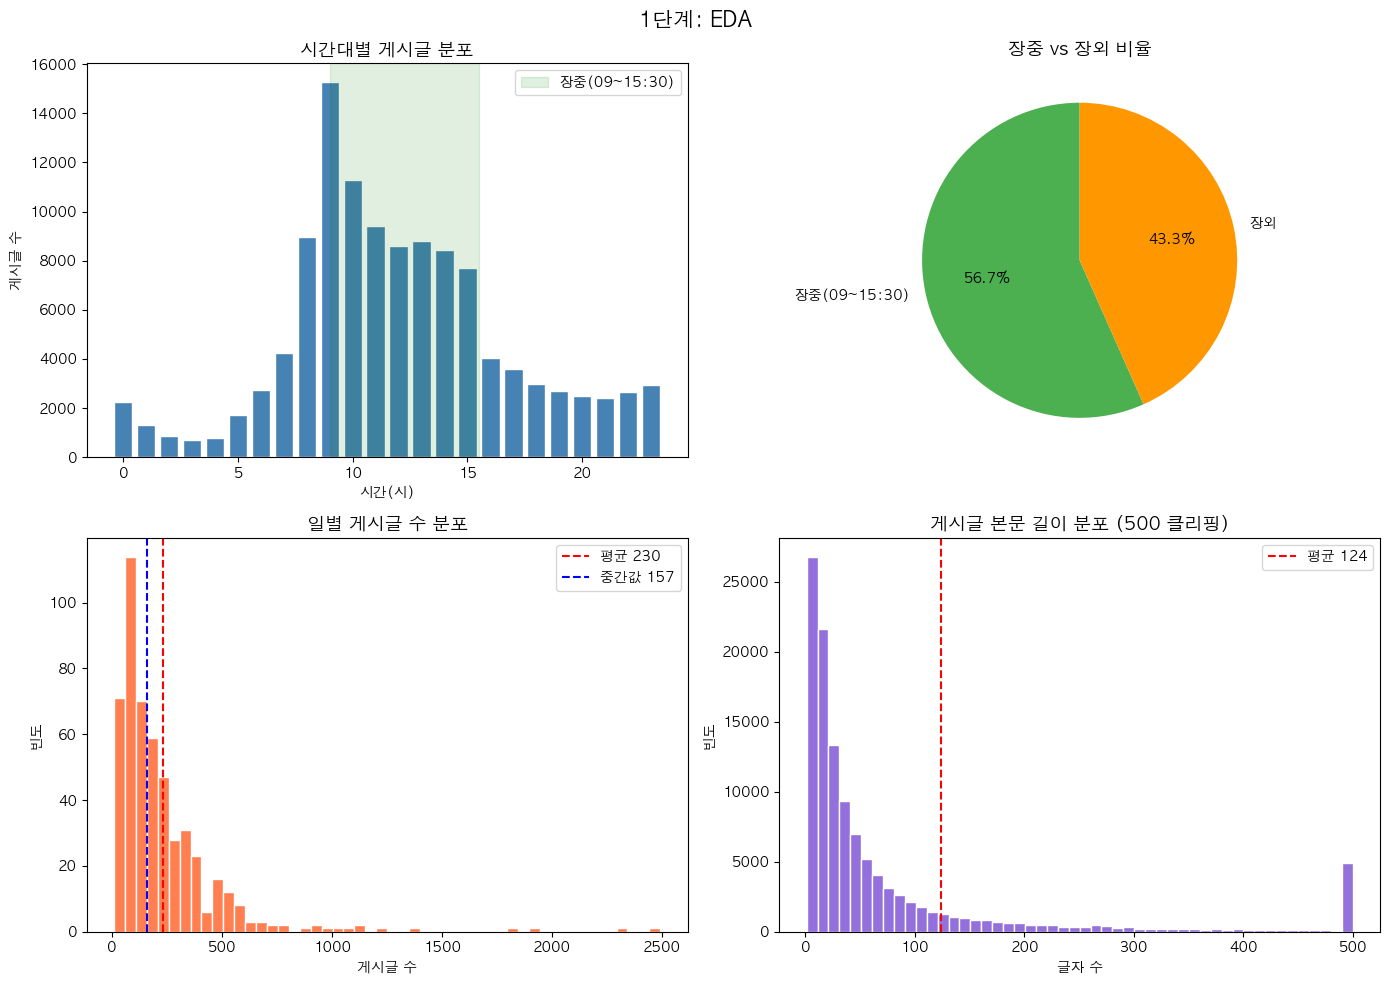

In [13]:
# ── EDA 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 시간대별 게시글
hour_dist = board_df['hour'].value_counts().sort_index()
axes[0,0].bar(hour_dist.index, hour_dist.values, color='steelblue', edgecolor='white')
axes[0,0].axvspan(9, 15.5, alpha=0.12, color='green', label='장중(09~15:30)')
axes[0,0].set_title('시간대별 게시글 분포', fontsize=13, fontweight='bold')
axes[0,0].set_xlabel('시간(시)')
axes[0,0].set_ylabel('게시글 수')
axes[0,0].legend()

# 2. 장중/장외 파이
axes[0,1].pie([n_market, n_total-n_market],
              labels=['장중(09~15:30)', '장외'],
              autopct='%1.1f%%',
              colors=['#4CAF50','#FF9800'], startangle=90)
axes[0,1].set_title('장중 vs 장외 비율', fontsize=13, fontweight='bold')

# 3. 일별 게시글 수 히스토그램
axes[1,0].hist(daily_counts.values, bins=50, color='coral', edgecolor='white')
axes[1,0].axvline(daily_counts.mean(),   color='red',  ls='--', label=f'평균 {daily_counts.mean():.0f}')
axes[1,0].axvline(daily_counts.median(), color='blue', ls='--', label=f'중간값 {daily_counts.median():.0f}')
axes[1,0].set_title('일별 게시글 수 분포', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('게시글 수')
axes[1,0].set_ylabel('빈도')
axes[1,0].legend()

# 4. body 길이 분포
axes[1,1].hist(board_df['body_len'].clip(0, 500), bins=50, color='mediumpurple', edgecolor='white')
axes[1,1].axvline(board_df['body_len'].mean(), color='red', ls='--',
                  label=f'평균 {board_df["body_len"].mean():.0f}')
axes[1,1].set_title('게시글 본문 길이 분포 (500 클리핑)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('글자 수')
axes[1,1].set_ylabel('빈도')
axes[1,1].legend()

plt.suptitle('1단계: EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'stage1_eda.png'), dpi=100, bbox_inches='tight')
plt.show()


## 2단계: 텍스트 전처리

In [14]:
# ============================================================
# 2단계: 텍스트 전처리
# ============================================================

# Step 1: 결측치 / 빈 문자열 제거
before = len(board_df)
board_df['body'] = board_df['body'].astype(str)
board_df = board_df[~board_df['body'].isin(['', 'nan', 'NaN', 'None'])]
board_df = board_df.dropna(subset=['body'])
board_df = board_df[board_df['body'].str.strip() != '']
after1 = len(board_df)
print(f"Step1 (결측치 제거):    {before:,} → {after1:,}  (제거 {before-after1:,})")

# Step 2: 광고글 제거 (동일 body 3회 이상)
body_cnt  = board_df['body'].value_counts()
ad_bodies = set(body_cnt[body_cnt >= 3].index)
board_df  = board_df[~board_df['body'].isin(ad_bodies)]
after2 = len(board_df)
print(f"Step2 (광고글 제거):    {after1:,} → {after2:,}  (제거 {after1-after2:,}, 광고유형 {len(ad_bodies)}개)")

# Step 3: 노이즈 제거
STOPWORDS = {
    '은','는','이','가','를','의','에','와','과','도','로','에서','까지',
    '부터','만','처럼','한','하다','있다','없다','것','수','그','저',
    '나','우리','합니다','입니다','있습니다','없습니다','합','됩'
}

def clean_text(text):
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)   # URL
    text = re.sub(r'[^가-힣a-zA-Z\s]', ' ', text)          # 특수문자·숫자
    text = re.sub(r'\s+', ' ', text).strip()
    return text

board_df['body_clean'] = board_df['body'].apply(clean_text)
board_df = board_df[board_df['body_clean'].str.strip() != '']
after3 = len(board_df)
print(f"Step3 (노이즈 제거):    {after2:,} → {after3:,}")

# 샘플 확인
print("\n전처리 샘플:")
for _, row in board_df.head(3).iterrows():
    print(f"  원본: {str(row['body'])[:60]}...")
    print(f"  정제: {row['body_clean'][:60]}...")
    print()


Step1 (결측치 제거):    116,849 → 116,849  (제거 0)
Step2 (광고글 제거):    116,849 → 107,433  (제거 9,416, 광고유형 914개)
Step3 (노이즈 제거):    107,433 → 106,052

전처리 샘플:
  원본: H20 만들어서 중국에 판다 호재...
  정제: H 만들어서 중국에 판다 호재...

  원본: 삼성전자도 못따라오는 ai기술 sk하이닉스에 몰빵하세요

하반기 실적 선반영합니다

젠슨 황 ceo를 믿으세...
  정제: 삼성전자도 못따라오는 ai기술 sk하이닉스에 몰빵하세요 하반기 실적 선반영합니다 젠슨 황 ceo를 믿으세요...

  원본: 하이닉스는 좋은기업인데
코스피지수 꼭대기에 20만원밑이라
부담스럽다
지수꺽이면 16만 직행인데 허허...
  정제: 하이닉스는 좋은기업인데 코스피지수 꼭대기에 만원밑이라 부담스럽다 지수꺽이면 만 직행인데 허허...



In [15]:
# Step 4: 형태소 분석 (KoNLPy Okt) — 캐시 활용
CACHE_FILE = os.path.join(CACHE_DIR, 'morpheme_tokens.pkl')

okt = Okt()

def tokenize_okt(text):
    try:
        pos_tags = okt.pos(text, stem=True)
        tokens = [
            word for word, tag in pos_tags
            if tag in ('Noun', 'Verb', 'Adjective', 'Adverb')
            and word not in STOPWORDS
            and len(word) > 1
        ]
        return tokens
    except Exception:
        return []

# 겹치는 기간만 처리
board_overlap = board_df[
    (board_df['date_only'] >= overlap_start) &
    (board_df['date_only'] <= overlap_end)
].copy().reset_index(drop=True)

print(f"겹치는 기간 게시글: {len(board_overlap):,}건")

if os.path.exists(CACHE_FILE):
    print("캐시 로드 중...")
    with open(CACHE_FILE, 'rb') as f:
        token_cache = pickle.load(f)
    # 캐시 매핑: body_clean 기준
    board_overlap['tokens'] = board_overlap['body_clean'].map(
        lambda t: token_cache.get(t, None))
    board_overlap = board_overlap.dropna(subset=['tokens'])
    print(f"캐시 로드 완료: {len(board_overlap):,}건")
else:
    from tqdm import tqdm
    tqdm.pandas()
    board_overlap['tokens'] = board_overlap['body_clean'].progress_apply(tokenize_okt)
    board_overlap = board_overlap[board_overlap['tokens'].apply(len) > 0]

    token_cache = dict(zip(board_overlap['body_clean'], board_overlap['tokens']))
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(token_cache, f)
    print(f"형태소 분석 완료: {len(board_overlap):,}건  (캐시 저장)")

# 형태소 길이 분포 → MAX_LEN 결정
token_lengths = board_overlap['tokens'].apply(len)
p90 = int(token_lengths.quantile(0.90))
p95 = int(token_lengths.quantile(0.95))
print(f"\n형태소 길이 분포:")
print(f"  평균: {token_lengths.mean():.1f}  |  중간값: {token_lengths.median():.1f}")
print(f"  90 퍼센타일: {p90}  |  95 퍼센타일: {p95}")

MAX_LEN = p90 if abs(p90 - 70) > 10 else 70
print(f"  사용할 MAX_LEN: {MAX_LEN}  (90% 커버리지 기준)")


겹치는 기간 게시글: 106,036건


  6%|▌         | 6062/106036 [00:16<04:27, 373.32it/s]


KeyboardInterrupt: 

In [ ]:
# Step 5 & 6: 토큰화 + 패딩
VOCAB_SIZE = 20000

board_overlap['tokens_str'] = board_overlap['tokens'].apply(lambda x: ' '.join(x))

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(board_overlap['tokens_str'])
print(f"어휘 사전: {len(tokenizer.word_index):,}개  (상위 {VOCAB_SIZE:,}개 사용)")

board_overlap['sequences'] = tokenizer.texts_to_sequences(board_overlap['tokens_str'])

padded_arr = pad_sequences(
    board_overlap['sequences'].tolist(),
    maxlen=MAX_LEN, padding='post', truncating='post')

board_overlap['padded'] = list(padded_arr)

print(f"패딩 완료  |  시퀀스 shape: {padded_arr.shape}")
print(f"최종 게시글 수: {len(board_overlap):,}")


## 3단계: 주가 데이터 가공

In [ ]:
# 3단계: 주가 데이터 가공 (종속변수 생성)

stock_df = stock_df.sort_values('date').reset_index(drop=True)

# r_t : 익일 주가 이동 방향
stock_df['next_close'] = stock_df['close'].shift(-1)
stock_df['r'] = (stock_df['next_close'] >= stock_df['close']).astype(int)

# R_t : 익일 주가 변동폭
stock_df['daily_range']  = stock_df['high'] - stock_df['low']
stock_df['next_range']   = stock_df['daily_range'].shift(-1)
delta = stock_df['next_range'].median()
stock_df['R'] = (stock_df['next_range'] >= delta).astype(int)

# 마지막 행 제거 (익일 없음)
stock_df = stock_df.dropna(subset=['next_close', 'next_range']).reset_index(drop=True)

print("종속변수 생성")
print(f"익일 변동폭 임계값 δ = {delta:.0f}원")

r_vc = stock_df['r'].value_counts().sort_index()
R_vc = stock_df['R'].value_counts().sort_index()
print(f"\nr (방향):  0(하락)={r_vc.get(0,0)}건 ({r_vc.get(0,0)/len(stock_df)*100:.1f}%)  "
      f"1(상승)={r_vc.get(1,0)}건 ({r_vc.get(1,0)/len(stock_df)*100:.1f}%)")
print(f"R (변동폭): 0(좁음)={R_vc.get(0,0)}건 ({R_vc.get(0,0)/len(stock_df)*100:.1f}%)  "
      f"1(넓음)={R_vc.get(1,0)}건 ({R_vc.get(1,0)/len(stock_df)*100:.1f}%)")

display(stock_df[['date','open','high','low','close','daily_range',
                   'next_close','next_range','r','R']].head(10))
print(f"\n주가 샘플 수: {len(stock_df)}")


## 4단계: 독립변수-종속변수 매칭

### 방식 A — 날짜별 그룹 단위 (논문 방식)

In [ ]:
# 4단계 - 방식 A: 날짜별 그룹 단위 (논문 방식)
trading_day_set = set(stock_df['date'].dt.date)
trading_days_sorted = sorted(trading_day_set)

def next_trading_day(d):
    for td in trading_days_sorted:
        if td > d:
            return td
    return None

def assign_trading_day(post_date, hour, minute):
    '''
    - 거래일 장중(09:00~15:30) → 당일
    - 거래일 장후(15:30 초과) / 비거래일 → 다음 거래일
    '''
    is_after = (hour > 15) or (hour == 15 and minute > 30)
    if (post_date in trading_day_set) and not is_after:
        return post_date
    return next_trading_day(post_date)

board_overlap['assigned_day'] = board_overlap.apply(
    lambda r: assign_trading_day(r['date_only'], r['hour'], r['minute']), axis=1)
board_overlap = board_overlap.dropna(subset=['assigned_day'])
board_overlap['assigned_day'] = pd.to_datetime(board_overlap['assigned_day'])

stock_label = stock_df[['date','r','R']].copy()
stock_label['date'] = pd.to_datetime(stock_label['date'])

# 날짜별 그룹화 + 집계
method_a_rows = []
groups = board_overlap.groupby('assigned_day')

for day, grp in groups:
    lbl = stock_label[stock_label['date'] == day]
    if lbl.empty:
        continue
    r_lbl = int(lbl['r'].values[0])
    R_lbl = int(lbl['R'].values[0])

    pads = np.array(grp['padded'].tolist())        # (n, MAX_LEN)
    texts = grp['tokens_str'].tolist()

    # A-concat: 모든 토큰을 이어붙인 후 MAX_LEN 패딩
    all_tok = []
    for t in texts:
        all_tok.extend(t.split())
    seq_c = tokenizer.texts_to_sequences([' '.join(all_tok[:MAX_LEN])])[0]
    seq_concat = pad_sequences([seq_c], maxlen=MAX_LEN,
                                padding='post', truncating='post')[0]

    # A-mean: 패딩된 시퀀스의 요소별 평균 (float)
    seq_mean = pads.mean(axis=0)

    method_a_rows.append({
        'day'       : day,
        'r'         : r_lbl,
        'R'         : R_lbl,
        'n_posts'   : len(grp),
        'seq_concat': seq_concat,
        'seq_mean'  : seq_mean,
        'tfidf_text': ' '.join(texts),
    })

method_a_df = (pd.DataFrame(method_a_rows)
               .sort_values('day').reset_index(drop=True))

print(f"\n방식 A 최종 샘플 수: {len(method_a_df)}")
print(f"거래일당 게시글 수 — 평균: {method_a_df['n_posts'].mean():.1f}  "
      f"중간값: {method_a_df['n_posts'].median():.1f}  "
      f"최소: {method_a_df['n_posts'].min()}  최대: {method_a_df['n_posts'].max()}")
display(method_a_df[['day','r','R','n_posts']].head(10))


### 방식 B — 개별 게시글 단위 (샘플 수 확보)

In [ ]:
# 4단계 - 방식 B: 개별 게시글 단위
stock_label = stock_df[['date','r','R']].copy()
stock_label['date'] = pd.to_datetime(stock_label['date'])

method_b_df = (board_overlap
               .merge(stock_label,
                      left_on='assigned_day', right_on='date',
                      how='inner')
               .sort_values('date_x')
               .reset_index(drop=True))

method_b_df = method_b_df.rename(columns={'date_x': 'post_dt'})

print(f"방식 B 최종 샘플 수: {len(method_b_df):,}")
r_vc = method_b_df['r'].value_counts().sort_index()
R_vc = method_b_df['R'].value_counts().sort_index()
print(f"  r=0: {r_vc.get(0,0):,}  r=1: {r_vc.get(1,0):,}")
print(f"  R=0: {R_vc.get(0,0):,}  R=1: {R_vc.get(1,0):,}")
display(method_b_df[['post_dt','assigned_day','r','R','tokens_str']].head(5))


In [ ]:
# Train / Val / Test 분리 (시계열 순서 유지, shuffle 금지)
def ts_split_seq(df, feat_col, tgt_col):
    '''시계열 split → 앞80% train, train 내 뒤20% val, 뒤20% test'''
    n = len(df)
    tr_end  = int(n * 0.8)
    val_sta = int(tr_end * 0.8)

    X_all  = np.array(df[feat_col].tolist())
    y_all  = df[tgt_col].values

    X_tr, y_tr = X_all[:val_sta],  y_all[:val_sta]
    X_vl, y_vl = X_all[val_sta:tr_end], y_all[val_sta:tr_end]
    X_te, y_te = X_all[tr_end:],  y_all[tr_end:]
    return X_tr, X_vl, X_te, y_tr, y_vl, y_te

def ts_split_tfidf(df, tgt_col, text_col):
    '''TF-IDF split (fit은 train에서만)'''
    n = len(df)
    tr_end  = int(n * 0.8)
    val_sta = int(tr_end * 0.8)

    texts = df[text_col].tolist()
    y_all = df[tgt_col].values

    tfidf_loc = TfidfVectorizer(max_features=5000)
    X_tr = tfidf_loc.fit_transform(texts[:val_sta]).toarray()
    X_vl = tfidf_loc.transform(texts[val_sta:tr_end]).toarray()
    X_te = tfidf_loc.transform(texts[tr_end:]).toarray()

    y_tr = y_all[:val_sta]
    y_vl = y_all[val_sta:tr_end]
    y_te = y_all[tr_end:]
    return X_tr, X_vl, X_te, y_tr, y_vl, y_te, tfidf_loc

# ── 방식 A ──
Ac_r  = ts_split_seq(method_a_df, 'seq_concat', 'r')
Ac_R  = ts_split_seq(method_a_df, 'seq_concat', 'R')
Am_r  = ts_split_seq(method_a_df, 'seq_mean',   'r')
Am_R  = ts_split_seq(method_a_df, 'seq_mean',   'R')
Atf_r = ts_split_tfidf(method_a_df, 'r', 'tfidf_text')
Atf_R = ts_split_tfidf(method_a_df, 'R', 'tfidf_text')

# ── 방식 B ──
B_r   = ts_split_seq(method_b_df, 'padded', 'r')
B_R   = ts_split_seq(method_b_df, 'padded', 'R')
Btf_r = ts_split_tfidf(method_b_df, 'r', 'tokens_str')
Btf_R = ts_split_tfidf(method_b_df, 'R', 'tokens_str')

nA = len(method_a_df)
nB = len(method_b_df)
print(f"방식A  총 {nA}개 → train {int(nA*0.64)}, val {int(nA*0.16)}, test {int(nA*0.2)}")
print(f"방식B  총 {nB}개 → train {int(nB*0.64):,}, val {int(nB*0.16):,}, test {int(nB*0.2):,}")


## 5단계: 모델 구축
### 5-1. 베이스라인 (TF-IDF + 분류기)

In [ ]:
# 5단계 - 베이스라인 모델 (Logistic Regression + Random Forest)
def eval_metrics(y_test, y_pred):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    pval = binomtest(int(acc * len(y_test)), len(y_test), 0.5,
                     alternative='greater').pvalue
    return acc, prec, rec, f1, pval

def run_baseline(splits, method, target, model_name):
    X_tr, X_vl, X_te, y_tr, y_vl, y_te = splits[:6]
    X_train_full = np.vstack([X_tr, X_vl])
    y_train_full = np.concatenate([y_tr, y_vl])

    if model_name == 'LogisticRegression':
        clf = LogisticRegression(max_iter=1000, random_state=42)
    else:
        clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

    clf.fit(X_train_full, y_train_full)
    y_pred = clf.predict(X_te)
    acc, prec, rec, f1, pval = eval_metrics(y_te, y_pred)
    return {
        'method': method, 'target': target,
        'model_type': model_name, 'agg': 'tfidf',
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1': f1, 'p_value': pval, 'n_test': len(y_te),
        'overfitting': False,
    }

baseline_results = []
tasks = [
    (Atf_r, 'A', 'r'), (Atf_R, 'A', 'R'),
    (Btf_r, 'B', 'r'), (Btf_R, 'B', 'R'),
]
print("베이스라인 학습 중...\n")
for splits, mth, tgt in tasks:
    for mname in ['LogisticRegression', 'RandomForest']:
        res = run_baseline(splits, mth, tgt, mname)
        baseline_results.append(res)
        flag = '✓' if res['p_value'] < 0.05 else ' '
        print(f"  방식{mth} {tgt} {mname:20s}: "
              f"acc={res['accuracy']:.4f}  f1={res['f1']:.4f}  p={res['p_value']:.4f} {flag}")

baseline_df = pd.DataFrame(baseline_results)
print("\n베이스라인 결과:")
display(baseline_df[['method','target','model_type','accuracy','f1','p_value']])


### 5-2. 딥러닝 모델 정의

In [ ]:
# 5단계 - 딥러닝 모델 정의
EMBED_DIM = 64
DROPOUT   = 0.3
EPOCHS    = 50
BATCH_SZ  = 64
PATIENCE  = 5

LSTM_UNITS  = [16, 32, 64, 128]
CNN_FILTERS = [32, 64, 128]
CNN_UNITS   = [16, 32, 64]

def build_lstm(units):
    m = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
        LSTM(units),
        Dropout(DROPOUT),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_cnn(n_filters, n_units):
    m = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
        Conv1D(n_filters, kernel_size=3, activation='relu', padding='same'),
        GlobalMaxPooling1D(),
        Dense(n_units, activation='relu'),
        Dropout(DROPOUT),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_cnn_lstm(n_filters, n_units):
    m = Sequential([
        Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),
        Conv1D(n_filters, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        LSTM(n_units),
        Dropout(DROPOUT),
        Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
    return m

print(f"LSTM 뉴런 후보:  {LSTM_UNITS}")
print(f"CNN 필터 후보:   {CNN_FILTERS}")
print(f"Dense 뉴런 후보: {CNN_UNITS}")
print(f"Embed={EMBED_DIM}, Dropout={DROPOUT}, Epochs={EPOCHS}, Batch={BATCH_SZ}, Patience={PATIENCE}")


## 6단계: 딥러닝 학습 및 평가

In [ ]:
# 6단계: 딥러닝 학습 및 평가
dl_results   = []
best_history = {}   # key: (method, target, agg, model_type)

def fit_model(model, X_tr, y_tr, X_vl, y_vl):
    es = EarlyStopping(monitor='val_loss', patience=PATIENCE, restore_best_weights=True)
    hist = model.fit(X_tr, y_tr,
                     validation_data=(X_vl, y_vl),
                     epochs=EPOCHS, batch_size=BATCH_SZ,
                     callbacks=[es], verbose=0)
    return hist

def predict_eval(model, X_te, y_te):
    proba = model.predict(X_te, verbose=0).flatten()
    y_pred = (proba > 0.5).astype(int)
    acc, prec, rec, f1, pval = eval_metrics(y_te, y_pred)
    return acc, prec, rec, f1, pval

def check_overfit(hist):
    ta = hist.history['accuracy'][-1]
    va = hist.history['val_accuracy'][-1]
    return (ta - va) > 0.10

def update_best(key, acc, hist, params):
    if key not in best_history or acc > best_history[key]['acc']:
        best_history[key] = {'acc': acc, 'hist': hist, 'params': params}

def run_dl(X_tr, X_vl, X_te, y_tr, y_vl, y_te, method, target, agg):
    tag = f"방식{method}_{target}_{agg or 'seq'}"

    # LSTM
    for u in LSTM_UNITS:
        tf.keras.backend.clear_session()
        model = build_lstm(u)
        hist  = fit_model(model, X_tr, y_tr, X_vl, y_vl)
        acc, prec, rec, f1, pval = predict_eval(model, X_te, y_te)
        ovfit = check_overfit(hist)
        key = (method, target, agg, 'LSTM')
        update_best(key, acc, hist, f'units={u}')
        dl_results.append({'method':method,'target':target,'agg':agg,
                            'model_type':'LSTM','n_units':u,'n_filters':None,
                            'accuracy':acc,'precision':prec,'recall':rec,
                            'f1':f1,'p_value':pval,'overfitting':ovfit})
        flag = ' ⚠️' if ovfit else ''
        print(f"  {tag} LSTM(u={u:3d}): acc={acc:.4f} f1={f1:.4f} p={pval:.4f}{flag}")

    # CNN
    for nf in CNN_FILTERS:
        for nu in CNN_UNITS:
            tf.keras.backend.clear_session()
            model = build_cnn(nf, nu)
            hist  = fit_model(model, X_tr, y_tr, X_vl, y_vl)
            acc, prec, rec, f1, pval = predict_eval(model, X_te, y_te)
            ovfit = check_overfit(hist)
            key = (method, target, agg, 'CNN')
            update_best(key, acc, hist, f'filters={nf},units={nu}')
            dl_results.append({'method':method,'target':target,'agg':agg,
                                'model_type':'CNN','n_units':nu,'n_filters':nf,
                                'accuracy':acc,'precision':prec,'recall':rec,
                                'f1':f1,'p_value':pval,'overfitting':ovfit})
            flag = ' ⚠️' if ovfit else ''
            print(f"  {tag} CNN(f={nf:3d},u={nu:3d}): acc={acc:.4f} f1={f1:.4f} p={pval:.4f}{flag}")

    # CNN+LSTM
    for nf in CNN_FILTERS:
        for nu in CNN_UNITS:
            tf.keras.backend.clear_session()
            model = build_cnn_lstm(nf, nu)
            hist  = fit_model(model, X_tr, y_tr, X_vl, y_vl)
            acc, prec, rec, f1, pval = predict_eval(model, X_te, y_te)
            ovfit = check_overfit(hist)
            key = (method, target, agg, 'CNN+LSTM')
            update_best(key, acc, hist, f'filters={nf},units={nu}')
            dl_results.append({'method':method,'target':target,'agg':agg,
                                'model_type':'CNN+LSTM','n_units':nu,'n_filters':nf,
                                'accuracy':acc,'precision':prec,'recall':rec,
                                'f1':f1,'p_value':pval,'overfitting':ovfit})
            flag = ' ⚠️' if ovfit else ''
            print(f"  {tag} CNN+LSTM(f={nf:3d},u={nu:3d}): acc={acc:.4f} f1={f1:.4f} p={pval:.4f}{flag}")

# ── 방식 A concat ──
print("\n[방식A - concat - r]")
run_dl(*Ac_r, 'A', 'r', 'concat')
print("\n[방식A - concat - R]")
run_dl(*Ac_R, 'A', 'R', 'concat')

# ── 방식 A mean ──
print("\n[방식A - mean - r]")
run_dl(*Am_r, 'A', 'r', 'mean')
print("\n[방식A - mean - R]")
run_dl(*Am_R, 'A', 'R', 'mean')

# ── 방식 B ──
print("\n[방식B - r]")
run_dl(*B_r, 'B', 'r', None)
print("\n[방식B - R]")
run_dl(*B_R, 'B', 'R', None)

dl_df = pd.DataFrame(dl_results)
print(f"\n딥러닝 총 실험 수: {len(dl_df)}")


## 7단계: 결과 정리

In [ ]:
# 7단계: 결과 정리

# 전체 결과 통합
all_df = pd.concat([baseline_df, dl_df], ignore_index=True, sort=False)

def model_label(row):
    if pd.notna(row.get('model_type')):
        if row['model_type'] in ('LogisticRegression','RandomForest'):
            return row['model_type']
        if pd.notna(row.get('n_filters')):
            return f"{row['model_type']}(f={int(row['n_filters'])},u={int(row['n_units'])})"
        return f"{row['model_type']}(u={int(row['n_units'])})"
    return str(row.get('model',''))

all_df['model_label'] = all_df.apply(model_label, axis=1)

# 1. 최적 모델 요약 테이블
print("1. 방식×목표변수별 최적 모델")

best_rows = []
for (mth, tgt), grp in all_df.groupby(['method','target']):
    best = grp.loc[grp['accuracy'].idxmax()]
    best_rows.append({
        '방식'      : f"방식{mth}",
        '목표변수'  : tgt,
        '모델'      : best.get('model_type', best.get('model','')),
        '집계'      : str(best.get('agg','-')),
        '파라미터'  : best['model_label'],
        '정확도'    : round(best['accuracy'], 4),
        'F1'        : round(best['f1'], 4),
        'p-value'   : round(best['p_value'], 4),
        '유의(p<.05)': '✓' if best['p_value'] < 0.05 else '✗',
        '과적합'    : '⚠️' if best.get('overfitting', False) else '-',
    })

display(pd.DataFrame(best_rows))

# 2. 베이스라인 vs 딥러닝 비교
print("2. 베이스라인 vs 딥러닝 비교")

cmp_rows = []
for (mth, tgt), grp in all_df.groupby(['method','target']):
    bl = grp[grp['model_type'].isin(['LogisticRegression','RandomForest'])]
    dl = grp[~grp['model_type'].isin(['LogisticRegression','RandomForest'])]
    best_bl_acc = bl['accuracy'].max() if not bl.empty else float('nan')
    best_dl_acc = dl['accuracy'].max() if not dl.empty else float('nan')
    cmp_rows.append({
        '방식': f"방식{mth}", '목표변수': tgt,
        '베이스라인 최고 Acc': round(best_bl_acc, 4),
        '딥러닝 최고 Acc'   : round(best_dl_acc, 4),
        '차이(DL-BL)'       : round(best_dl_acc - best_bl_acc, 4),
    })
display(pd.DataFrame(cmp_rows))

# 3. 전체 하이퍼파라미터 조합 결과
print("3. 전체 하이퍼파라미터 조합 결과 (딥러닝)")
display(dl_df[['method','target','agg','model_type','n_filters','n_units',
               'accuracy','f1','p_value','overfitting']]
        .sort_values(['method','target','accuracy'], ascending=[True,True,False])
        .reset_index(drop=True))


In [ ]:
# 4. 하이퍼파라미터별 평균 정확도 막대 그래프
combos = [('A','r','concat'),('A','R','concat'),
          ('A','r','mean'),  ('A','R','mean'),
          ('B','r',None),    ('B','R',None)]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()
COLORS = {'LSTM':'#4C72B0','CNN':'#DD8452','CNN+LSTM':'#55A868'}

for ax, (mth, tgt, agg) in zip(axes, combos):
    sub = dl_df[(dl_df['method']==mth) &
                (dl_df['target']==tgt) &
                (dl_df['agg'].apply(lambda x: x==agg if agg else pd.isna(x) or x is None))]
    if sub.empty:
        ax.set_visible(False)
        continue
    grp_acc = sub.groupby('model_type')['accuracy'].mean()
    bars = ax.bar(grp_acc.index, grp_acc.values,
                  color=[COLORS.get(k,'gray') for k in grp_acc.index],
                  edgecolor='white', linewidth=0.8)
    ax.axhline(0.5, color='red', ls='--', lw=1.5, label='50% baseline')
    title = f"방식{mth}-{tgt}" + (f"\n집계:{agg}" if agg else "")
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('평균 정확도')
    ax.set_ylim(0.3, 0.85)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, grp_acc.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('하이퍼파라미터별 평균 정확도 (딥러닝)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'stage7_accuracy_bars.png'), dpi=100, bbox_inches='tight')
plt.show()

# LSTM 유닛 수별 정확도 꺾은선
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
lstm_sub = dl_df[dl_df['model_type']=='LSTM']
for ax, tgt in zip(axes, ['r','R']):
    for mth in ['A','B']:
        s = lstm_sub[(lstm_sub['method']==mth) & (lstm_sub['target']==tgt)]
        if s.empty: continue
        g = s.groupby('n_units')['accuracy'].mean()
        ax.plot(g.index, g.values, marker='o', label=f'방식{mth}')
    ax.axhline(0.5, color='red', ls='--', label='50%')
    ax.set_title(f'LSTM 유닛 수 vs 정확도 (목표: {tgt})', fontweight='bold')
    ax.set_xlabel('LSTM 유닛 수')
    ax.set_ylabel('평균 정확도')
    ax.legend()
    ax.set_xticks(LSTM_UNITS)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'stage7_lstm_units.png'), dpi=100, bbox_inches='tight')
plt.show()

# CNN 필터 수별 정확도
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cnn_sub = dl_df[dl_df['model_type'].isin(['CNN','CNN+LSTM'])]
for ax, tgt in zip(axes, ['r','R']):
    for mtype in ['CNN','CNN+LSTM']:
        s = cnn_sub[(cnn_sub['model_type']==mtype) & (cnn_sub['target']==tgt)]
        if s.empty: continue
        g = s.groupby('n_filters')['accuracy'].mean()
        ax.plot(g.index, g.values, marker='s', label=mtype)
    ax.axhline(0.5, color='red', ls='--', label='50%')
    ax.set_title(f'CNN 필터 수 vs 정확도 (목표: {tgt})', fontweight='bold')
    ax.set_xlabel('필터 수')
    ax.set_ylabel('평균 정확도')
    ax.legend()
    ax.set_xticks(CNN_FILTERS)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'stage7_cnn_filters.png'), dpi=100, bbox_inches='tight')
plt.show()


In [ ]:
# 5. 최적 모델 학습 곡선
if best_history:
    keys = list(best_history.keys())[:6]
    n = len(keys)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = axes.reshape(1, -1)

    for idx, key in enumerate(keys):
        info  = best_history[key]
        h     = info['hist'].history
        mth, tgt, agg, mtype = key
        ep    = range(1, len(h['loss'])+1)

        axes[idx,0].plot(ep, h['loss'],     label='Train Loss', color='steelblue')
        axes[idx,0].plot(ep, h['val_loss'], label='Val Loss',   color='darkorange')
        axes[idx,0].set_title(f'방식{mth} {tgt} {mtype} [{info["params"]}] — Loss',
                               fontsize=10)
        axes[idx,0].set_xlabel('Epoch')
        axes[idx,0].set_ylabel('Loss')
        axes[idx,0].legend()

        axes[idx,1].plot(ep, h['accuracy'],     label='Train Acc', color='steelblue')
        axes[idx,1].plot(ep, h['val_accuracy'], label='Val Acc',   color='darkorange')
        ta = h['accuracy'][-1]; va = h['val_accuracy'][-1]
        if ta - va > 0.10:
            axes[idx,1].text(0.5, 0.05, '⚠️ 과적합 의심',
                             transform=axes[idx,1].transAxes,
                             color='red', fontsize=10, ha='center',
                             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
        axes[idx,1].set_title(f'방식{mth} {tgt} {mtype} [{info["params"]}] — Accuracy',
                               fontsize=10)
        axes[idx,1].set_xlabel('Epoch')
        axes[idx,1].set_ylabel('Accuracy')
        axes[idx,1].legend()

    plt.suptitle('최적 모델 학습 곡선', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'stage7_learning_curves.png'),
                dpi=100, bbox_inches='tight')
    plt.show()
    print("학습 곡선 저장 완료")
else:
    print("학습 곡선 데이터 없음")


In [ ]:
# 6. 방식 A vs 방식 B 비교
print("6. 방식 A vs 방식 B 성능 비교")

ab_rows = []
for tgt in ['r','R']:
    for mth in ['A','B']:
        sub_dl = dl_df[(dl_df['method']==mth) & (dl_df['target']==tgt)]
        sub_bl = baseline_df[(baseline_df['method']==mth) & (baseline_df['target']==tgt)]
        ab_rows.append({
            '목표변수': tgt,
            '방식': f'방식{mth}',
            '샘플수': len(method_a_df) if mth=='A' else len(method_b_df),
            'BL 최고 Acc': round(sub_bl['accuracy'].max(), 4) if not sub_bl.empty else '-',
            'DL 최고 Acc': round(sub_dl['accuracy'].max(), 4) if not sub_dl.empty else '-',
            'DL 최고 F1' : round(sub_dl.loc[sub_dl['accuracy'].idxmax(),'f1'], 4)
                           if not sub_dl.empty else '-',
            '통계유의(DL)': '✓' if not sub_dl.empty and
                            sub_dl.loc[sub_dl['accuracy'].idxmax(),'p_value'] < 0.05
                            else '✗',
        })

display(pd.DataFrame(ab_rows))

# 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt in zip(axes, ['r','R']):
    data, labels = [], []
    for mth in ['A','B']:
        sub = dl_df[(dl_df['method']==mth) & (dl_df['target']==tgt)]['accuracy']
        if not sub.empty:
            data.append(sub.values); labels.append(f'방식{mth}')
    if data:
        bp = ax.boxplot(data, labels=labels, patch_artist=True)
        for patch, c in zip(bp['boxes'], ['#4C72B0','#DD8452']):
            patch.set_facecolor(c); patch.set_alpha(0.7)
    ax.axhline(0.5, color='red', ls='--', label='50% baseline')
    ax.set_title(f'방식 A vs B 정확도 분포  (목표: {tgt})', fontweight='bold')
    ax.set_ylabel('정확도')
    ax.legend()
plt.suptitle('방식 A vs 방식 B 비교', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'stage7_ab_compare.png'), dpi=100, bbox_inches='tight')
plt.show()

# ── 최종 결론 ──
print("최종 결론")
best_overall = all_df.loc[all_df['accuracy'].idxmax()]
print(f"전체 최고 정확도: {best_overall['accuracy']:.4f}")
print(f"  방식: {best_overall.get('method','')}  목표변수: {best_overall.get('target','')}  "
      f"모델: {best_overall['model_label']}")

sig = all_df[all_df['p_value'] < 0.05]
print(f"\n통계적으로 유의미한 결과 수 (p < 0.05): {len(sig)}")
if not sig.empty:
    print("  유의미한 조합:")
    display(sig[['method','target','model_label','accuracy','p_value']].head(10))
